# Generative AI Lab Notebook: From Machine Learning to Generative AI
This lab will take you from BERT-style understanding to using Generative AI using a small LLM.

1. Define goals
2. Architectural and conceptual differences
3. Setup our model environment
4. Basic generation with a simple prompt
5. Prompting: Compare the output quality
6. Control output with parameters
7. Compare sampling methods
8. A simple zero-shot prompted task
9. More structured prompting
10. Few-shot prompting
11. More control variables: length and tokens
12. How models see tokens and why counts matter
13. Attention
14. Wrap-up


## 1. Learning Objectives
By the end of this lab, you should be able to:
- Explain the difference between encoder-style and decoder-style models.
- Generate text with a causal language model.
- Control output style with prompt wording and sampling settings.
- Describe what tokens are and why they matter.
- Explain attention at a high level.
- Use more structured prompts to get more useful results.


## 2. Architectural Shift
- **BERT (Encoder):** Reads full context, left and right, to understand meaning.
- **GenAI (Decoder):** Generates one token at a time using prior tokens.

### Key Transition Concepts
- **From Classification → Generation:** Outputs are sequences, not labels.
- **From Static Input → Dynamic Output:** The model keeps producing tokens until stopped.
- **From Masking → Prompting:** Instructions replace `[MASK]` tokens.
- **Determinism vs Variability:** The same prompt can produce different results.
- **No single correct answer:** Outputs are judged by usefulness, clarity, and alignment with intent.
- **Prompt quality matters:** Better instructions usually produce better outputs.


## 3. Environment Setup

In [1]:
from transformers import pipeline, set_seed
import transformers
import logging
import warnings

# Suppress Python warnings and HuggingFace logger noise
warnings.filterwarnings('ignore')
transformers.logging.set_verbosity_error()
logging.getLogger('transformers').setLevel(logging.ERROR)

MODEL_NAME = 'TinyLlama/TinyLlama-1.1B-Chat-v1.0'

# eager attention is required to extract attention weights in section 13.
# sdpa (the default) uses a fused CUDA kernel that does not expose them.
generator = pipeline(
    'text-generation',
    model=MODEL_NAME,
    model_kwargs={'attn_implementation': 'eager'},
)

# Reuse the tokenizer that the pipeline already loaded
tokenizer = generator.tokenizer

set_seed(42)

print(f'Model loaded: {MODEL_NAME}')
print(f'Parameters : ~{generator.model.num_parameters()/1e9:.1f}B')

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Model loaded: TinyLlama/TinyLlama-1.1B-Chat-v1.0
Parameters : ~1.1B


## 4. Warm-Up: Basic Generation
Start with a simple prompt and let the model continue it.

### Key Insight
- Generation is sequential. The model extends the text instead of selecting a label.

In [2]:
prompt = 'The future of artificial intelligence is'

outputs = generator(
    prompt,
    max_new_tokens=30,
    num_return_sequences=1,
    do_sample=True,
)

print(outputs[0]['generated_text'])

The future of artificial intelligence is the future of our world. How will AI shape the global economy? How will it affect our daily lives? What challenges will it pose for


## 5. Compare Prompt Quality
Here we keep the topic similar, but improve the instruction. Watch how output quality changes.

### Key Insight
- Prompt wording is now part of your workflow. Clear prompts usually give clearer outputs.

In [3]:
weak_prompt = 'Write about AI.'
better_prompt = 'Write three concise sentences explaining how AI may change healthcare over the next 10 years.'

weak_out = generator(weak_prompt, max_new_tokens=40, do_sample=True)
better_out = generator(better_prompt, max_new_tokens=60, do_sample=True)

print('--- Weak Prompt ---')
print(weak_out[0]['generated_text'])

print('\n--- Better Prompt ---')
print(better_out[0]['generated_text'])

--- Weak Prompt ---
Write about AI. How does it impact the entertainment industry? Can you provide specific examples?

--- Better Prompt ---
Write three concise sentences explaining how AI may change healthcare over the next 10 years. Use specific examples and provide supporting evidence.


## 6. Task: Controlling Creativity
Adjust randomness with sampling parameters.

### Key Concepts
- **Temperature:** Higher values increase randomness.
- **do_sample=True:** Allows variation.
- Same prompt can yield different outputs depending on settings.

In [4]:
prompt = 'The future of artificial intelligence is'

creative_out = generator(
    prompt,
    temperature=1.2,
    do_sample=True,
    max_new_tokens=35,
)

logical_out = generator(
    prompt,
    temperature=0.2,
    do_sample=True,
    max_new_tokens=35,
)

print('--- Creative ---')
print(creative_out[0]['generated_text'])

print('\n--- Logical ---')
print(logical_out[0]['generated_text'])

--- Creative ---
The future of artificial intelligence is not binary. There will be advantages and disadvantages of AI that change rapidly over time, making it difficult to predict, however most humans will experience a period of increased

--- Logical ---
The future of artificial intelligence is bright, but it's not without its challenges. In this episode, we explore the potential impact of AI on various industries, including healthcare, finance


## 7. Task: Top-K and Top-P Sampling
Temperature is not the only control. We can also limit which next-token choices the model considers.

### Key Concepts
- **Top-K:** Keep only the K most likely next tokens.
- **Top-P (nucleus sampling):** Keep the smallest set of tokens whose combined probability reaches P.
- These settings help balance creativity and coherence.

In [5]:
sample_prompt = 'A robot assistant entered the classroom and'

# temperature is intentionally omitted so that Top-K vs Top-P is the only variable
topk_out = generator(
    sample_prompt,
    do_sample=True,
    top_k=20,
    max_new_tokens=40,
)

topp_out = generator(
    sample_prompt,
    do_sample=True,
    top_p=0.8,
    max_new_tokens=40,
)

print('--- Top-K Output ---')
print(topk_out[0]['generated_text'])

print('\n--- Top-P Output ---')
print(topp_out[0]['generated_text'])

--- Top-K Output ---
A robot assistant entered the classroom and began to guide the students in a lesson. SARAH: (excited) Hey, I’m so glad you’re here! ANNIE: (smiling)

--- Top-P Output ---
A robot assistant entered the classroom and began to read out a list of numbers.

Student 1: "One, two, three, four, five, six, seven, eight, nine, ten, eleven, twelve,


## 8. Task: Zero-Shot Prompting
Use instructions to guide the model without fine-tuning.

### Key Insight
- The model can perform many tasks from natural language instructions alone.

In [6]:
instruction_prompt = '''Translate the following English text to French:
English: I love learning about neural networks.
French:'''

result = generator(instruction_prompt, max_new_tokens=20, do_sample=True)

print(result[0]['generated_text'])

Translate the following English text to French:
English: I love learning about neural networks.
French: Je profite des systèmes des neurones.

Based on the given material, please


## 9. Task: More Structured Prompting
Now move beyond a single instruction. Provide role, task, format, and constraints.

### Prompt Design Pattern
- **Role**
- **Task**
- **Format**
- **Constraints**

This is still simple, but it shows how structured prompts often improve output.

In [7]:
structured_prompt = '''You are a helpful technical writing assistant.
Task: Explain what a neural network is.
Format: Return exactly 3 bullet points.
Constraints: Use plain language, avoid math, and keep each bullet under 15 words.
Answer:
'''

structured_result = generator(
    structured_prompt,
    max_new_tokens=80,
    do_sample=True,
    temperature=0.5,
)

print(structured_result[0]['generated_text'])

You are a helpful technical writing assistant.
Task: Explain what a neural network is.
Format: Return exactly 3 bullet points.
Constraints: Use plain language, avoid math, and keep each bullet under 15 words.
Answer:
A neural network is a type of artificial neural system that learns from data by simulating the functioning of the human brain. It consists of a network of nodes connected by weights and biases, with each node processing information and updating its own weights based on the input it receives. The network then outputs a result based on the weighted combination of the input and the current output.

Ex


## 10. Task: Few-Shot Prompting
In zero-shot prompting, you only give instructions. In few-shot prompting, you also show examples.

### Key Insight
- Examples help the model imitate the pattern you want.

In [8]:
few_shot_prompt = '''Convert each item into a short label.

Input: A cyber analyst reviews alerts all morning.
Label: Threat Monitoring

Input: A nurse checks a patient's vital signs.
Label: Patient Care

Input: A teacher grades quizzes after class.
Label:'''

few_shot_result = generator(
    few_shot_prompt,
    max_new_tokens=12,
    do_sample=True,
    temperature=0.3,
)

print(few_shot_result[0]['generated_text'])

Convert each item into a short label.

Input: A cyber analyst reviews alerts all morning.
Label: Threat Monitoring

Input: A nurse checks a patient's vital signs.
Label: Patient Care

Input: A teacher grades quizzes after class.
Label: Assessment

Input: A customer service representative handles


## 11. Practical Controls You Need
- **`max_new_tokens`** controls how much new text gets added.
- **`max_length`** controls total length, including the prompt.
- Models do not automatically know when to stop unless constrained.
- Short, clear prompts are easier to control than vague prompts.

In [9]:
short_prompt = 'Give me two reasons to back up data regularly.'

short_out = generator(short_prompt, max_new_tokens=20, do_sample=True)
long_out = generator(short_prompt, max_new_tokens=60, do_sample=True)

print('--- Shorter Output ---')
print(short_out[0]['generated_text'])

print('\n--- Longer Output ---')
print(long_out[0]['generated_text'])

--- Shorter Output ---
Give me two reasons to back up data regularly.

--- Longer Output ---
Give me two reasons to back up data regularly.


## 12. How Models See Tokens and Why Counts Matter
Humans see words and sentences. The model sees **tokens**.

### Key Ideas
- Tokens can be full words, parts of words, punctuation, or symbols.
- Generation happens one token at a time.
- Prompt length matters because long prompts consume context space.
- More tokens can mean more cost, more latency, and less remaining context window.

In [10]:
text = 'Transformers process text token by token.'

token_ids = tokenizer.encode(text)
decoded_tokens = [tokenizer.decode([tok]) for tok in token_ids]

print('Original text:')
print(text)

print('\nToken IDs:')
print(token_ids)

print('\nDecoded tokens:')
print(decoded_tokens)

print(f'\nToken count: {len(token_ids)}')

Original text:
Transformers process text token by token.

Token IDs:
[1, 4103, 689, 414, 1889, 1426, 5993, 491, 5993, 29889]

Decoded tokens:
['<s>', 'Trans', 'form', 'ers', 'process', 'text', 'token', 'by', 'token', '.']

Token count: 10


Now compare token counts across prompts that look similar to humans but differ to the model.

In [11]:
prompts = [
    'Explain AI.',
    'Explain artificial intelligence in simple terms.',
    'Explain artificial intelligence in simple terms for a high school student in three sentences.'
]

for p in prompts:
    ids = tokenizer.encode(p)
    print(f'Prompt: {p}')
    print(f'Token count: {len(ids)}')
    print('-' * 60)

Prompt: Explain AI.
Token count: 6
------------------------------------------------------------
Prompt: Explain artificial intelligence in simple terms.
Token count: 9
------------------------------------------------------------
Prompt: Explain artificial intelligence in simple terms for a high school student in three sentences.
Token count: 17
------------------------------------------------------------


## 13. Attention: How the Model Chooses What Matters
Attention helps the model weigh earlier tokens when predicting the next token.

### Intuition
Not every token in the sequence matters equally when generating the next one.
Attention lets the model assign weights to earlier tokens — higher weight means more influence.

In the sentence:
> The cat that chased the bird was hungry.

When predicting a word that follows "was", the model should pay most attention to
**cat**, **chased**, and **bird** — the semantically meaningful tokens — and
less to function words like "the" or "that".

### What we will do
- Extract attention weights from TinyLlama for one input sentence.
- Look at a single attention head from layer 0.
- Visualize which tokens received the most attention.

### What to keep in mind
- A model has many layers and multiple heads per layer. We are only looking at one.
- **Early layers like layer 0 tend to look fairly uniform** — they handle positional
  and structural patterns rather than semantics. That is expected and normal.
- Deeper layers develop more specialized, selective patterns.
- Different heads often specialize: some track syntax, others track semantics.
- This is a simplified view. Real attention is multi-dimensional.


In [12]:
import torch

attention_text = "The cat that chased the bird was hungry"
inputs = tokenizer(attention_text, return_tensors="pt")

device = generator.model.device
inputs = {k: v.to(device) for k, v in inputs.items()}

captured = {}

def hook_fn(module, input, output):
    if isinstance(output, tuple) and len(output) > 1 and output[1] is not None:
        captured['attn'] = output[1].detach().cpu().to(torch.float32)

layer_idx = 0
head_idx  = 0
hook = generator.model.model.layers[layer_idx].self_attn.register_forward_hook(hook_fn)

with torch.no_grad():
    generator.model(**inputs, output_attentions=True)

hook.remove()

last_token_attn = captured['attn'][0, head_idx, -1, :].numpy()
tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])

print(f"Layer {layer_idx}, Head {head_idx} — attention from last token to each input token:\n")
for tok, weight in zip(tokens, last_token_attn):
    bar = '█' * int(weight * 40)
    print(f"  {tok:<14} {weight:.4f}  {bar}")

Layer 0, Head 0 — attention from last token to each input token:

  <s>            0.0864  ███
  ▁The           0.0962  ███
  ▁cat           0.0908  ███
  ▁that          0.0840  ███
  ▁ch            0.0923  ███
  ased           0.0903  ███
  ▁the           0.0928  ███
  ▁bird          0.0918  ███
  ▁was           0.0874  ███
  ▁hun           0.0898  ███
  gry            0.0977  ███


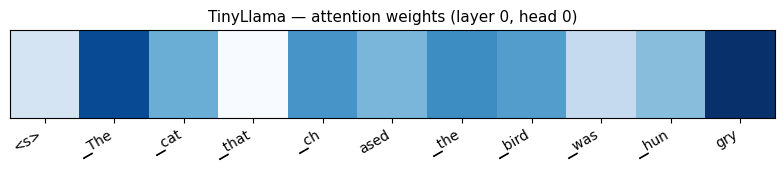

In [13]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 1.8))
ax.imshow(last_token_attn.reshape(1, -1), aspect='auto', cmap='Blues')
ax.set_xticks(range(len(tokens)))
ax.set_xticklabels(tokens, rotation=30, ha='right', fontsize=10)
ax.set_yticks([])
ax.set_title(
    f'TinyLlama — attention weights (layer {layer_idx}, head {head_idx})',
    fontsize=11
)
plt.tight_layout()
plt.show()


## 14. Wrap-Up
In this lab, you shifted from understanding-oriented models to generation-oriented models.

### Main Takeaways
- BERT reads and classifies. GenAI writes and continues.
- Prompting is a core skill — wording, structure, and examples all shape output.
- Sampling settings (temperature, Top-K, Top-P) control variation.
- Tokens are the units the model processes. Prompt length has real cost.
- Attention lets the model focus on the most relevant earlier tokens.
